# Procesamiento Digital de Imágenes - Prácticas Integradas (TP00 y TP01)

### Introducción y Configuración Inicial
Para la realización de las actividades prácticas, utilizaremos **Python** y la biblioteca de visión computacional **OpenCV**.

OpenCV es una herramienta muy potente, y por defecto carga las imágenes en el espacio de color **BGR** en lugar de **RGB**, y utiliza el tipo de dato **uint8**, lo cual debemos tener en cuenta al operar.

Usaremos **Matplotlib** porque nos da mucha flexibilidad en la visualización, a diferencia de OpenCV usa por defecto **RGB**.

**Importante en entorno Google Colab**: La función estándar `cv2.imshow()` bloquea el entorno web y no está permitida. En su lugar, utilizaremos `matplotlib` para la visualización o el parche oficial de Colab `cv2_imshow`.



## Manejar las imágenes en colab

### Acceder a datos de Google Drive desde Colab

1. En el panel de la izquierda (*Archivos*), ir a "Activar unidad de Drive" o bien, utilizar un código en una celda:

      `from google.colab import drive`

      `drive.mount('/content/drive')`

2. En cualquier caso, te pedirá que te autentifiques.

3. Ya puedes acceder a tu Google Drive en `/content/drive`. La recomendación es que centralices los ejercicios e imágenes en una carpeta específica de tu Drive.

### Usar datos temporales desde Colab

1. En el panel de la izquierda (*Subir al almacenamiento de sesión*), puedes subir un archivo y usarlo temporalmente hasta que cierres la sesión. Puedes acceder desde `/content/`






In [12]:
#from google.colab import drive
#drive.mount('/content/drive')

## Configuración e Importación

A continuación puedes ver las librerías que utilizaremos, como importarlas y como visualizar la versión instalada.

Recuerda que para instalar una librería puedes usar:

```
# !pip install xxxx
```



In [13]:
import sys
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
#from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
from ipywidgets import interact, IntSlider, FloatSlider

print(f"Versión de Python: {sys.version}")
print(f"Versión de OpenCV (cv2): {cv.__version__}")
print(f"Versión de NumPy: {np.__version__}")
print(f"Versión de Matplotlib: {plt.matplotlib.__version__}")
print(f"Versión de ipywidgets: {widgets.__version__}")

# Para librerías que no tienen un atributo __version__ o si quieres más detalles, puedes usar pip
# !pip show pandas # Por ejemplo, para pandas si estuviera instalado

Versión de Python: 3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]
Versión de OpenCV (cv2): 4.13.0
Versión de NumPy: 2.4.3
Versión de Matplotlib: 3.10.8
Versión de ipywidgets: 8.1.8


## Hello World!: Cargar/guardar una imagen y ver sus propiedades

* El primer paso es cargar una imagen, analizar sus propiedades y guardarla.

* Acordate que la imagen es una matriz y por tanto es válido usar las funciones de numpy para hacer operaciones, por ejemplo: `np.mean(), np.min(), np.max()`.



* Podés ver la imagen que guardaste en la carpeta temporal del colab.


In [14]:
# TODO: Sube una imagen
# Ahora carga de imagen (desde el Drive o de la carpeta temporal)
imagen = cv.imread('../imagenes_cursado/botellas.jpg')

if imagen is None:
    print("Error: No se encontró la imagen. Asegúrate de subirla al entorno de Colab.")
else:
    # Información sobre la imagen
    print("--- Información de la Imagen ---")
    print("Dimensiones (FILAS, COLUMNAS, CANALES):", imagen.shape)
    print("Tipo de dato:", imagen.dtype)
    print("Número total de píxeles (elementos):", imagen.size)
    print("Tamaño en bytes:", imagen.nbytes)
    print("")
    print("Para toda la imagen(BGR), valor medio %.3f, mínimo %d, máximo %d" %(np.mean(imagen),np.min(imagen),np.max(imagen)))
    print("Para el canal Azul, valor medio %.3f, mínimo %d, máximo %d\n" %(np.mean(imagen[:,:,0]),np.min(imagen[:,:,0]),np.max(imagen[:,:,0])))

    print("Para el canal Verde, valor medio %.3f, mínimo %d, máximo %d\n" %(np.mean(imagen[:,:,1]),np.min(imagen[:,:,1]),np.max(imagen[:,:,1])))
    print("Para el canal Rojo, valor medio %.3f, mínimo %d, máximo %d\n" %(np.mean(imagen[:,:,2]),np.min(imagen[:,:,2]),np.max(imagen[:,:,2])))

    # Guardado de la imagen
    cv.imwrite('nueva_imagen.jpg', imagen)
    print("Imagen guardada como 'nueva_imagen.jpg'.")



--- Información de la Imagen ---
Dimensiones (FILAS, COLUMNAS, CANALES): (196, 285, 3)
Tipo de dato: uint8
Número total de píxeles (elementos): 167580
Tamaño en bytes: 167580

Para toda la imagen(BGR), valor medio 92.379, mínimo 0, máximo 255
Para el canal Azul, valor medio 92.379, mínimo 0, máximo 255

Para el canal Verde, valor medio 92.379, mínimo 0, máximo 255

Para el canal Rojo, valor medio 92.379, mínimo 0, máximo 255

Imagen guardada como 'nueva_imagen.jpg'.


Notas:

la función `imread` convierte la imagen en una matriz de números en tres dimensiones.

`imagen.shape` el shape esta compuesto por:
- Eje x
- Eje y
- Eje z: 3 canales, BGR, que aislan la informacion de cada componente del color

Cada celda representa la intensidad de la luz para ese canal especifico
- 0 ausencia total de color (negro)
- 255 intensidad maxima de ese color


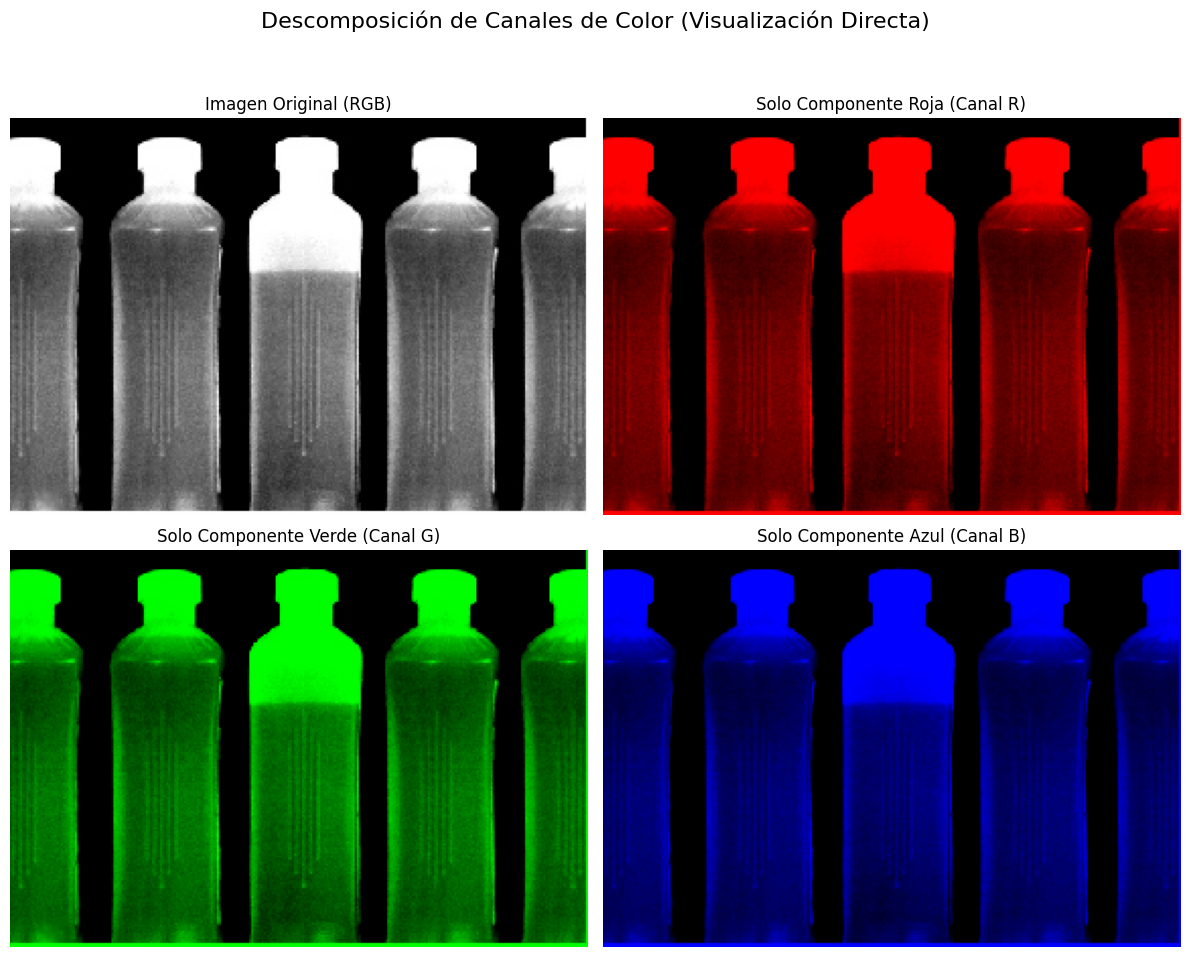

In [15]:
imagen_rgb = cv.cvtColor(imagen, cv.COLOR_BGR2RGB) #convert color

R = imagen_rgb[:, :, 0]
G = imagen_rgb[:, :, 1]
B = imagen_rgb[:, :, 2]

ceros = np.zeros_like(R)


solo_rojo = np.dstack((R, ceros, ceros))    # R activa, G y B negras
solo_verde = np.dstack((ceros, G, ceros))   # G activa, R y B negras
solo_azul = np.dstack((ceros, ceros, B))    # B activa, R y G negras

    # 5. Configurar el plot con subplots (axs)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Descomposición de Canales de Color (Visualización Directa)', fontsize=16)

    # --- Plot Original ---
axs[0, 0].imshow(imagen_rgb)
axs[0, 0].set_title('Imagen Original (RGB)')
axs[0, 0].axis('off') # Quitar ejes para estética

    # --- Plot Canal Rojo ---
axs[0, 1].imshow(solo_rojo)
axs[0, 1].set_title('Solo Componente Roja (Canal R)')
axs[0, 1].axis('off')

    # --- Plot Canal Verde ---
axs[1, 0].imshow(solo_verde)
axs[1, 0].set_title('Solo Componente Verde (Canal G)')
axs[1, 0].axis('off')

    # --- Plot Canal Azul ---
axs[1, 1].imshow(solo_azul)
axs[1, 1].set_title('Solo Componente Azul (Canal B)')
axs[1, 1].axis('off')

    # Mostrar todo
plt.tight_layout() # Ajustar espaciado
plt.subplots_adjust(top=0.9) # Espacio para el título principal
plt.show()



diferencias:
- cv.imread(): crea el tensor BGR
- cv.cvtColor(imagen, cv.Color): significa convert color, toma una matriz de imagenes en BGR y lo convierte a otro espacio (regulado por cv.COLOR)


Recorrer imagen:
- imagen[ancho,alto] identifica un pixel y este pixel tiene asociado un array con 3 componentes 

In [16]:
imagen[2,2]

array([0, 0, 0], dtype=uint8)

## Visualización de imagen y ROI (subimagen)

Para copiar imágenes de forma segura en memoria, debes usar la función .copy().

Además, podemos trabajar con Regiones de Interés (ROI) recortando la matriz de la imagen mediante indexación de Numpy.


In [17]:
def mostrar_imagen(imagen, titulo="Imagen", cmap=None):
    plt.figure(figsize=(6, 6))
    if cmap is None and len(imagen.shape) == 3: 
        # Recordar la diferencia de como manejan los canales openCV y Matplotlib
        imagen = cv.cvtColor(imagen, cv.COLOR_BGR2RGB) # sobreescribe laimagen
    plt.imshow(imagen, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

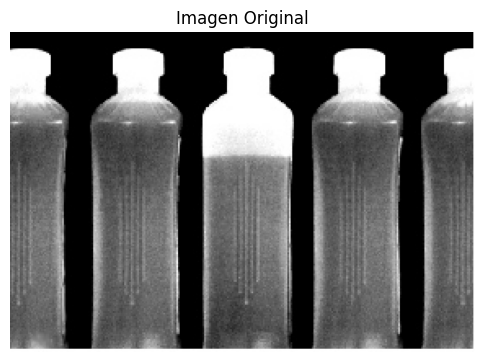

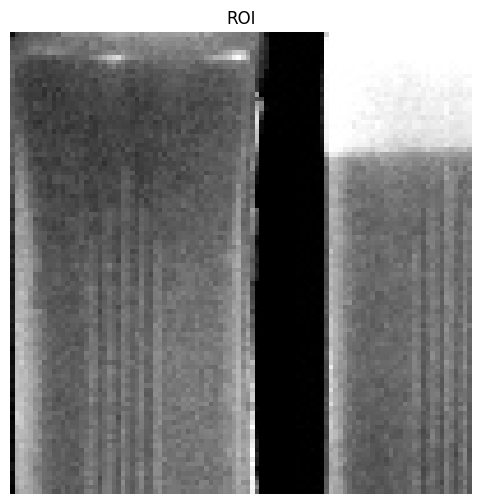

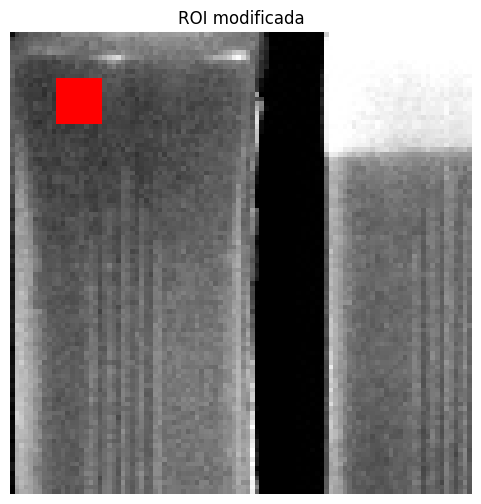

In [18]:
# Mostrar la imagen original
mostrar_imagen(imagen, "Imagen Original")

# Extraer una ROI (subimagen) y copiar en memoria
imagen_ROI = imagen[50:150, 50:150].copy()
# Mostrar la ROI
mostrar_imagen(imagen_ROI, "ROI")

# Acceder y modificar un píxel/área específica
# Convertiremos un cuadrado de 10x10 píxeles en rojo en la ROI
imagen_ROI[10:20, 10:20] = (0, 0, 255)  # BGR: Azul=0, Verde=0, Rojo=255
mostrar_imagen(imagen_ROI, "ROI modificada")



**Preguntas:**

* ¿Cuántos canales tiene la imagen botellas.jpg?
* ¿La imagen se ve en color o en grises?
* ¿Qué está pasando con los canales, que información tienen?
* ¿Porqué usé esta asignación:

```
# imagen_ROI[10:20, 10:20] = (0, 0, 255)
```
y no esta:
```
# imagen_ROI[10:20, 10:20] = 255
```




1) tiene 3 canales, Azul, verde y Rojo
2) Se ve en colores (en gris), pero usa los 3 componentes para describirlo
3) tienen informacion de la intensidad de color del canal respectivo en ese pixel
4) porque cada posicion de imagen (pixel) guarda un array de 3 componentes asociadas a la intensidad de cada canal.

## Graficación simple y visualización múltiple

Cuando quiero definir una imagen desde cero, la defino como una matriz multidimensional usando numpy. Puedo inicializarla con ceros (`np.zeros`) o unos (`np.ones`) según me convenga.

```
# imagen_nueva = np.zeros((ALTO, ANCHO, CANALES), dtype=TIPO_DE_DATO)
```
* El tipo de dato más usual es `np.uint8`

---

**OpenCV** tiene implementadas funciones para dibujar formas en una imagen.
* Investiga cuales son, además de las que vas a ver a continuación: `line, circle, rectangle`.
* También averigua que significan los parámetros que les pasamos
* Cambia los parámetros y fijate que pasa en el lienzo.
* Si querés agregar texto a una imagen, podes usar `cv.putText(imagen, "texto", ...)`. Revisá los parámetros de esta función.
    
---

* Analizá como estamos graficando, usando **matplotlib.pyplot**, para mostrar múltiples figuras en una sola ventana usando **subplot**. Ésto te va a resultar útil más adelante.

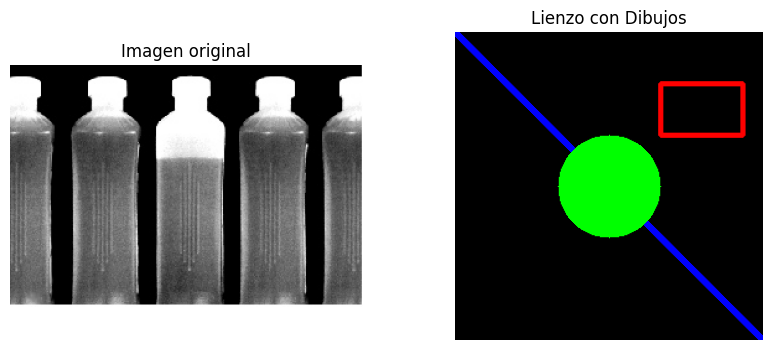

In [19]:
# Crear una imagen negra vacía de 300x300 con 3 canales
lienzo = np.zeros((300, 300, 3), dtype=np.uint8)

# Dibujar figuras geométricas
# TODO: Prueba cambiar los colores (recuerda que el orden es BGR), grosores y coordenadas
cv.line(lienzo, (0, 0), (300, 300), (255, 0, 0), 5)
cv.circle(lienzo, (150, 150), 50, (0, 255, 0), -1)
cv.rectangle(lienzo, (200, 50), (280, 100), (0, 0, 255), 3)

# Subplots
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB) if imagen is not None else lienzo)
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(lienzo, cv.COLOR_BGR2RGB))
plt.title("Lienzo con Dibujos")
plt.axis('off')
plt.show()

- cv.line(lienzo, pixel_init, pixel_end, color, grosor): dibujar una linea
- cv.circle(lienzo, pixel_init, pixel_end, color, grosor): dibujar una circulo, -1 el grosor relleno
- cv.rectangle: (lienzo, pixel_sup_izq, pixel_inf_der, color grosor)

En openCV las pocisiones (x,y), el (0,0) es la esquina superior izquierda.
- X representa columna
- Y representa fila

## Uso de Trackbars (ipywidgets)

El uso de componentes  interactivos te da flexibilidad y te hace la vida más sencilla. Por ejemplo, cuando vas a probar un conjunto de parámetros diferentes simplemente interactuas con los componentes, así no tenés que modificar el código y volverlo a correr 😋

Acá sólo vamos a mencionar algunos, podés explorar más acerca de  ([GUI](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html)).


---

En el **primer ejemplo** vas a usar un slider para seleccionar la fila a partir de la cual vas a obtener el **perfil de intensidad**.

* ¿Recordas que es el perfil de intensidad?
* ¿Que información útil te brinda?
* Fijate cómo obtenemos la imagen en grises desde la imagen BGR.
* Analiza que significan los parámetros del Widget (**interact**) y como se asocia el widget a la función:
```
# interact(plot_perfil_interactivo, fila=IntSlider(min=0, max=imagen_gris.shape[0]-1, step=1, value=imagen_gris.shape[0]//2))

```

---

En el **segundo ejemplo** vamos a usar la Trackbar para **Blending**

* ¿Sabés en que consiste la operación de blending (mezcla) de imágenes?

Básicamente es una suma pesada de dos imágenes utilizando un factor de mezcla `alpha` parta una y `beta = 1 - alpha` para la otra. Este valor `alpha` es real en el rango [0-1] y entonces usamos el componente `FloatSlider`.

Usamos esta funcion de OpenCV: **`cv2.addWeighted(img1, alpha, img2, beta, 0.0)`**:


In [20]:
def plot_perfil_interactivo(fila):
        # Analizaremos la fila de la imagen en grises
        
        plt.figure(figsize=(12, 4))
        # Mostrar en dónde estamos cortando la imagen
        plt.subplot(1, 2, 1)
        img_linea = cv.cvtColor(imagen_gris, cv.COLOR_GRAY2BGR)
        cv.line(img_linea, (0, fila), (img_linea.shape[1], fila), (255, 0, 0), 2)
        plt.imshow(cv.cvtColor(img_linea, cv.COLOR_BGR2RGB))
        plt.title(f"Línea de análisis: {fila}")
        plt.axis('off')

        # Graficar el perfil de intensidad
        perfil = imagen_gris[fila, :]
        plt.subplot(1, 2, 2)
        plt.plot(perfil)
        plt.title(f"Perfil de Intensidad(Fila {fila})")
        plt.ylim(0, 260)
        plt.xlabel("Columna (Píxel)")
        plt.ylabel("Intensidad (0-255)")
        plt.grid(True)
        plt.show()

# 1. Ejemplo interactivo: Perfil de Intensidad
if imagen is not None:
    imagen_gris = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY)

    # Widget para mover la línea de análisis
    interact(plot_perfil_interactivo, fila=IntSlider(min=0, max=imagen_gris.shape[0]-1, step=1, value=imagen_gris.shape[0]//2))


interactive(children=(IntSlider(value=98, description='fila', max=195), Output()), _dom_classes=('widget-inter…

In [21]:
# 2. Ejemplo interactivo: Trackbar para Blending
def blending_interactivo(alpha):
    # Usamos dos imágenes del mismo tamaño para el ejemplo
    img1 = np.zeros((300,300,3), dtype=np.uint8)
    img1[:] = (255,0,0) # Qué hacemos acá?
    img2 = np.zeros((300,300,3), dtype=np.uint8)
    img2[:] = (0,0,255) # Qué hacemos acá?

    beta = 1.0 - alpha
    dst = cv.addWeighted(img1, alpha, img2, beta, 0.0)

    # Reusamos la función que definimos antes!
    mostrar_imagen(dst, f"Blending: Alpha={alpha:.2f}, Beta={beta:.2f}")

interact(blending_interactivo, alpha=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5))


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.05), Output()), _dom_classes…

<function __main__.blending_interactivo(alpha)>

## Trabajo de Aplicación - Inspección de Botellas

**Problema**: Identificar si una botella en una línea de envasado no está correctamente llena. Trabajarás con una imagen fija **"botella.jpg"** en escala de grises.

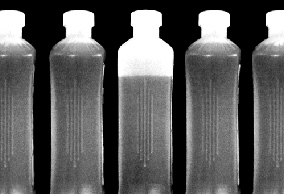


**Objetivos de la función:**
* Identificar la botella (podría ser cualquiera la que no está llena).
* Indicar la posición dibujando un recuadro alrededor de la botella.
* Estimar de forma simplificada el porcentaje de llenado. Aquí, cada uno es libre de elegir y justificar su criterio.

**Nota complementaria:** En esta etapa temprana de la materia, puedes usar enfoques simples basados en umbralización (thresholding) y recorte, aprovechando la intensidad de los píxeles (p.e. el líquido será más oscuro que el fondo iluminado).


**"¡y voilá!"** Ya tenés la primera aproximación a la resolución de un problema real (obvio, simplificado) con herramientas simples! 🙌🙌

### Cómo te ibamos a dejar a pata, acá te damos unas ayudas para la implementación, igual vos hacelo como más te guste porque hay varias formas de hacerlo!



In [ ]:
# Subí el archivo 'botella.jpg' a Colab si aun no lo hiciste
# Acá ya podés cargar la imagen en grises directamente, fijate el parámetro.
img_botella = cv.imread('botella.jpg', cv.IMREAD_GRAYSCALE)

def inspeccionar_llenado(imagen_botella):
    if imagen_botella is None:
        return "Por favor, carga la imagen 'botella.jpg'"

    resultado = cv.cvtColor(imagen_botella, cv.COLOR_GRAY2BGR)
    alto, ancho = imagen_botella.shape

    # -------------------------------------------------------------
    # COMPLETA EL ALGORITMO
    # -------------------------------------------------------------

    # PASO 1: Encontrar la botella (ej: buscar columnas más oscuras)
    # Hint: Podés usar np.mean(imagen_botella, axis=0) para ver

    resumen = np.mean(imagen_botella, axis=0) # promedia por columna
    
    # el perfil de columnas y encontrar dónde está la botella.

    # x_inicio = ...
    # x_fin = ...

    # PASO 2: Analizar el nivel de líquido dentro de la columna encontrada
    # Hint: Puedes buscar transiciones fuertes de intensidad en el eje Y.

    # y_liquido = ...

    # PASO 3: Calcular el porcentaje en base a un nivel "Lleno ideal" vs el detectado
    # porcentaje = ...

    # PASO 4: Dibujar un recuadro envolvente y el nivel
    # cv2.rectangle ...
    # Escribir texto en la imagen con OpenCV
    # cv2.putText...

    return resultado

# Mostrar resultado parcial (hasta que lo completes)
resultado_inspeccion = inspeccionar_llenado(img_botella)
if isinstance(resultado_inspeccion, str):
    print(resultado_inspeccion)
else:
    mostrar_imagen(resultado_inspeccion, titulo="Sistema de Inspección")

Por favor, carga la imagen 'botella.jpg'


(196, 285)
Columnas más oscuras (posibles botellas): [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50 103
 104 105 106 107 108 109 110 111 112 113 114 115 116 117 173 174 175 176
 177 178 179 180 181 182 183 184 185 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253]
[(0, np.int64(34)), (np.int64(34), np.int64(50)), (np.int64(103), np.int64(117)), (np.int64(173), np.int64(185))]


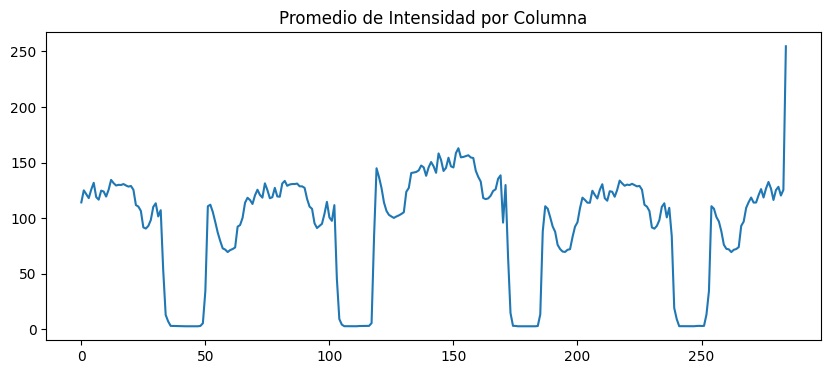

In [40]:
img_botella = cv.imread('../Imagenes_cursado/botellas.jpg', cv.IMREAD_GRAYSCALE)
print(img_botella.shape)

# busco los promedios

promedio_columnas = np.mean(img_botella, axis=0) # promedia por columna
plt.figure(figsize=(10, 4))
plt.plot(promedio_columnas)
plt.title("Promedio de Intensidad por Columna")


# defino un umbral menor que 50 y busco indices

index_oscuros = np.where(promedio_columnas < 50)[0]
print("Columnas más oscuras (posibles botellas):", index_oscuros)

indices_no_consecutivos= []
actual = 0

indices_no_consecutivos.append((0,index_oscuros[0]))
actual = index_oscuros[0]
for i in range(1, len(index_oscuros)):
    if index_oscuros[i] != index_oscuros[i-1] + 1:
        indices_no_consecutivos.append((actual,index_oscuros[i-1]))
        actual = index_oscuros[i]


print(indices_no_consecutivos)





